# NumPy, Pandas và Visualization

**Phiên bản:** Sinh viên - có TODO, không có đáp án

Notebook này đi cùng slide deck của buổi học. Mục tiêu là đi từ dữ liệu dạng số,
sang dữ liệu dạng bảng, rồi đến trực quan hóa để chuẩn bị cho workflow Machine Learning.

## Mục tiêu

- Dùng NumPy để suy nghĩ theo array, shape, dtype, broadcasting và mask.
- Dùng Pandas để đọc, inspect, clean, groupby và export dữ liệu dạng bảng.
- Dùng Matplotlib/Seaborn để debug dữ liệu và rút insight trước modeling.
- Luyện thêm vài thao tác biến đổi ảnh bằng NumPy để thấy array không chỉ là bảng số.

## 0. Setup

Chạy cell này trước. Notebook sẽ ưu tiên đọc `../data/penguins.csv`, phù hợp khi notebook nằm trong thư mục `notebooks/` của course.

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

DATA_CANDIDATES = [
    Path("../data/penguins.csv"),
    Path("/penguins.csv"),
    Path(r"C:\Users\phatl\OneDrive\Documents\Study Material\SummerCourse2026\data\penguins.csv"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy penguins.csv. Hãy đặt file ở ../data/penguins.csv")

df = pd.read_csv(DATA_PATH)
print("Data path:", DATA_PATH)
print("Shape:", df.shape)
df.head()

Data path: /penguins.csv
Shape: (344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## 1. NumPy: array, shape, dtype

NumPy array là cấu trúc nền cho tính toán số trong scientific Python stack.
Hai thông tin cần đọc gần như ngay lập tức là `shape` và `dtype`.

In [4]:
x = np.array([1, 2, 3, 4, 5])
X = np.array([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
    [7.0, 8.0, 9.0],
])

print("x:", x)
print("x.shape:", x.shape, "| x.dtype:", x.dtype, "| x.ndim:", x.ndim)
print("X.shape:", X.shape, "| X.dtype:", X.dtype, "| X.ndim:", X.ndim)

x: [1 2 3 4 5]
x.shape: (5,) | x.dtype: int64 | x.ndim: 1
X.shape: (3, 3) | X.dtype: float64 | X.ndim: 2


### 1.1 Python list và NumPy array

List phù hợp cho logic Python tổng quát và có thể chứa nhiều kiểu dữ liệu.
NumPy array đồng nhất dtype, có shape rõ ràng và hỗ trợ phép toán theo mảng.

In [5]:
python_values = [1, 2, 3, 4]
numpy_values = np.array(python_values)

doubled_list = [value * 2 for value in python_values]
doubled_array = numpy_values * 2

print("list:", doubled_list)
print("array:", doubled_array)
print("array shape/dtype:", numpy_values.shape, numpy_values.dtype)

list: [2, 4, 6, 8]
array: [2 4 6 8]
array shape/dtype: (4,) int64


### 1.2 Shape trong dữ liệu ML

Đọc shape theo ngữ nghĩa: `(samples, features)` cho bảng số,
`(H, W, C)` cho ảnh màu và `(B, H, W, C)` cho batch ảnh.
Một bẫy phổ biến: transpose của vector 1D vẫn có shape `(F,)`.

In [6]:
X_tabular = np.zeros((100, 5))
image_rgb = np.zeros((224, 224, 3), dtype=np.uint8)
image_batch = np.zeros((32, 224, 224, 3), dtype=np.uint8)
weights_1d = np.zeros(5)

print("tabular:", X_tabular.shape)
print("image:", image_rgb.shape)
print("batch:", image_batch.shape)
print("1D vector:", weights_1d.shape, "| transpose:", weights_1d.T.shape)
print("X @ w:", (X_tabular @ weights_1d).shape)

tabular: (100, 5)
image: (224, 224, 3)
batch: (32, 224, 224, 3)
1D vector: (5,) | transpose: (5,)
X @ w: (100,)


### 1.3 Dtype và bộ nhớ

Dtype quyết định số byte cho mỗi phần tử, miền giá trị và khả năng tương thích với model.
Ảnh thường được lưu ở `uint8`, sau đó đổi sang `float32` và chuẩn hóa về `[0, 1]`.

In [7]:
arrays = {
    "float64": np.ones((1000, 1000), dtype=np.float64),
    "float32": np.ones((1000, 1000), dtype=np.float32),
    "uint8": np.ones((1000, 1000), dtype=np.uint8),
}
for name, arr in arrays.items():
    print(f"{name:7s}: {arr.nbytes / 1e6:.1f} MB")

pixels = np.array([0, 128, 255], dtype=np.uint8)
pixels_f32 = pixels.astype(np.float32) / 255.0
print("normalized pixels:", pixels_f32, pixels_f32.dtype)

float64: 8.0 MB
float32: 4.0 MB
uint8  : 1.0 MB
normalized pixels: [0.        0.5019608 1.       ] float32


### 1.4 Vectorization

Thay vì lặp qua từng phần tử bằng Python loop, ta mô tả phép toán trên cả array.
Với dữ liệu lớn, tư duy này thường nhanh hơn và gần công thức toán hơn.

In [8]:
scores = np.array([68, 72, 90, 55, 80, 77], dtype=np.float32)
mean = scores.mean()
std = scores.std()
z_scores_loop = np.array([(score - mean) / std for score in scores])
z_scores = (scores - scores.mean()) / scores.std()

print("mean:", round(float(mean), 2))
print("std:", round(float(std), 2))
print("z-scores:", np.round(z_scores, 2))
print("same result:", np.allclose(z_scores_loop, z_scores))

mean: 73.67
std: 10.81
z-scores: [-0.52 -0.15  1.51 -1.73  0.59  0.31]
same result: True


In [9]:
rng = np.random.default_rng(42)
X_features = rng.normal(size=(100, 5))

# Sai mục tiêu: chuẩn hóa bằng một mean/std chung cho cả ma trận.
X_global = (X_features - X_features.mean()) / X_features.std()

# Đúng mục tiêu: mỗi feature có mean gần 0 và std gần 1.
X_per_feature = (
    (X_features - X_features.mean(axis=0))
    / X_features.std(axis=0)
)

print("global column means:", np.round(X_global.mean(axis=0), 2))
print("per-feature means:", np.round(X_per_feature.mean(axis=0), 2))
print("per-feature stds:", np.round(X_per_feature.std(axis=0), 2))

global column means: [-0.02 -0.01  0.04  0.02 -0.03]
per-feature means: [ 0. -0. -0. -0. -0.]
per-feature stds: [1. 1. 1. 1. 1.]


### 1.5 Broadcasting

Broadcasting giúp array có shape khác nhau vẫn tính được với nhau nếu các chiều tương thích.
Ví dụ phổ biến trong ML là chuẩn hóa từng feature của ma trận `(samples, features)`.

In [10]:
X = np.array([
    [1.0, 200.0, 0.1],
    [2.0, 220.0, 0.2],
    [3.0, 250.0, 0.4],
    [4.0, 270.0, 0.5],
])

feature_mean = X.mean(axis=0)
feature_std = X.std(axis=0)
X_scaled = (X - feature_mean) / feature_std

print("feature_mean:", np.round(feature_mean, 2))
print("feature_std:", np.round(feature_std, 2))
print(np.round(X_scaled, 2))

feature_mean: [  2.5 235.    0.3]
feature_std: [ 1.12 26.93  0.16]
[[-1.34 -1.3  -1.26]
 [-0.45 -0.56 -0.63]
 [ 0.45  0.56  0.63]
 [ 1.34  1.3   1.26]]


In [11]:
a = np.array([[1, 2, 3],
              [4, 5, 6]])
b = np.array([10, 20, 30])
print("a.shape:", a.shape, "| b.shape:", b.shape)
print(a + b)

a.shape: (2, 3) | b.shape: (3,)
[[11 22 33]
 [14 25 36]]


### 1.6 Indexing, slicing, boolean mask

Boolean mask là cách viết rất thường gặp khi lọc dữ liệu theo điều kiện.

In [12]:
values = np.array([3, 7, 2, 9, 12, 4, 8])
mask = values >= 7

print("mask:", mask)
print("values >= 7:", values[mask])
print("2 phần tử đầu:", values[:2])
print("các phần tử vị trí chẵn:", values[::2])

mask: [False  True False  True  True False  True]
values >= 7: [ 7  9 12  8]
2 phần tử đầu: [3 7]
các phần tử vị trí chẵn: [ 3  2 12  8]


### 1.7 View và copy

Slicing thường trả về view cùng chia sẻ bộ nhớ với array gốc.
Dùng `.copy()` khi cần một bản độc lập để sửa.

In [13]:
original = np.array([1, 2, 3, 4, 5])
view = original[1:4]
view[0] = 999

independent = original[1:4].copy()
independent[0] = 0

print("original:", original)
print("view shares memory:", np.shares_memory(original, view))
print("copy shares memory:", np.shares_memory(original, independent))

original: [  1 999   3   4   5]
view shares memory: True
copy shares memory: False


### Bài tập NumPy 1

Cho vector `v`, hãy chuẩn hóa về z-score: trừ trung bình và chia độ lệch chuẩn.
Sau đó kiểm tra mean gần 0 và std gần 1.

In [14]:
v = np.array([10, 12, 13, 15, 100], dtype=np.float32)

# TODO: tính v_z bằng z-score normalization
# v_z = ...
v_z = (v - v.mean())/v.std()
# TODO: in v_z, mean và std của v_z để tự kiểm tra
print(v_z)
print(v_z.mean().round(3))
print(v_z.std().round(3))

[-0.5708231  -0.5137408  -0.48519963 -0.42811733  1.9978808 ]
0.0
1.0


## 2. NumPy với ảnh: ảnh cũng là array

Một ảnh grayscale có thể xem như array shape `(H, W)`.
Ảnh RGB thường có shape `(H, W, 3)`.

image.shape: (140, 190) | min/max: (np.float64(0.05000000000000007), np.float64(1.0))


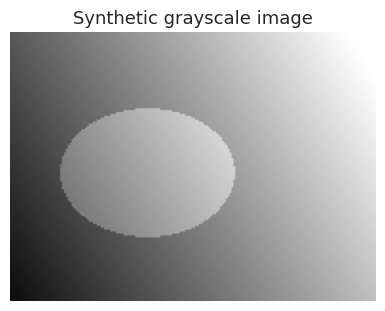

In [15]:
H, W = 140, 190
y, x = np.mgrid[-1:1:complex(H), -1:1:complex(W)]
base = 0.55 + 0.35 * x - 0.15 * y
circle = ((x + 0.25) ** 2 + (y - 0.05) ** 2) < 0.23
image = np.clip(base + circle * 0.2, 0, 1)

print("image.shape:", image.shape, "| min/max:", (image.min(), image.max()))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.imshow(image, cmap="gray", vmin=0, vmax=1)
ax.set_title("Synthetic grayscale image")
ax.axis("off");

### 2.1 Một vài biến đổi ảnh bằng slicing và phép toán array

Các thao tác này giúp thấy rõ: crop, flip, threshold, invert đều là phép toán trên array.

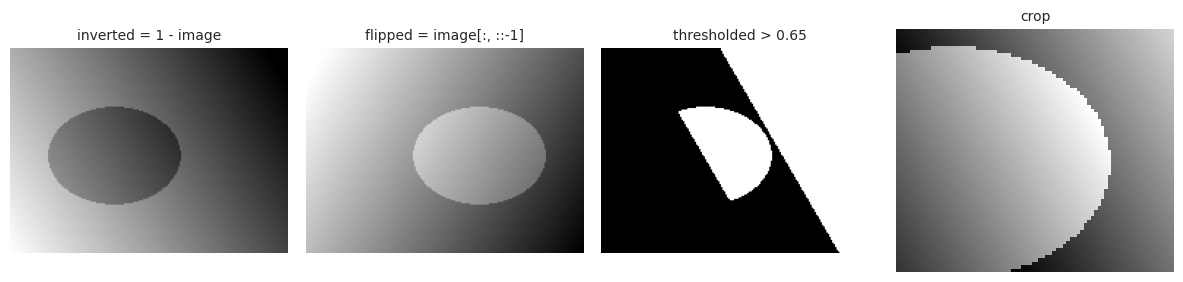

In [16]:
inverted = 1 - image
flipped = image[:, ::-1]
thresholded = image > 0.65
crop = image[35:105, 55:135]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
panels = [
    ("inverted = 1 - image", inverted, "gray"),
    ("flipped = image[:, ::-1]", flipped, "gray"),
    ("thresholded > 0.65", thresholded, "gray"),
    ("crop", crop, "gray"),
]
for ax, (title, arr, cmap) in zip(axes, panels):
    ax.imshow(arr, cmap=cmap)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()

### 2.2 Tạo ảnh RGB từ các channel

`np.dstack` có thể ghép ba channel `(H, W)` thành một ảnh `(H, W, 3)`.

rgb.shape: (140, 190, 3)


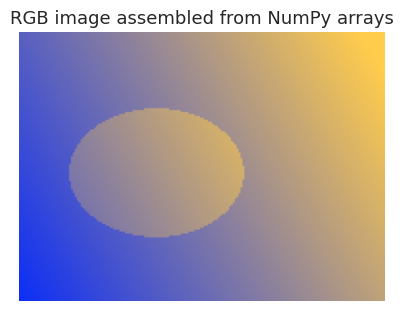

In [17]:
red = image
green = np.clip(image * 0.65 + 0.15, 0, 1)
blue = np.clip(1 - image * 0.7, 0, 1)
rgb = np.dstack([red, green, blue])

print("rgb.shape:", rgb.shape)
plt.figure(figsize=(5, 3.5))
plt.imshow(rgb)
plt.title("RGB image assembled from NumPy arrays")
plt.axis("off");

### Bài tập NumPy 2: biến đổi ảnh

Từ biến `image`, hãy tạo:

- `central_crop`: crop vùng trung tâm.
- `bright`: tăng độ sáng nhưng không vượt quá 1.
- `red_tint`: ảnh RGB trong đó kênh đỏ mạnh hơn hai kênh còn lại.

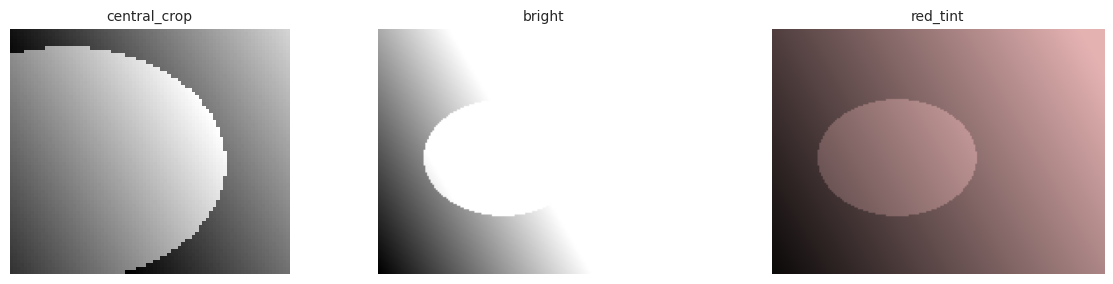

In [18]:
# TODO: crop vùng trung tâm của image
# central_crop = ...
central_crop = image[35:105, 55:135]
# TODO: tăng sáng và dùng np.clip để giữ giá trị trong [0, 1]
# bright = ...
bright = np.clip(base + circle * 0.2 + 0.5,0,1)
# TODO: tạo red_tint bằng np.dstack([...])
# red_tint = ...
red_tint = np.dstack([image, image, image])
red_tint[:,:,0] = np.clip(red_tint[:,:,0]*0.9 ,0,1)
red_tint[:,:,1] *= 0.7
red_tint[:,:,2] *= 0.7

# TODO: vẽ 3 ảnh trên cùng một figure
# Tạo khung gồm 1 hàng, 3 cột để chứa đủ 3 ảnh
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# Thêm red_tint vào danh sách các ảnh cần vẽ, lưu ý ảnh màu RGB không cần dùng cmap="gray"
panels = [
    ("central_crop", central_crop, "gray"),
    ("bright", bright, "gray"),
    ("red_tint", red_tint, None)
]

for ax, (title, arr, cmap) in zip(axes, panels):
    ax.imshow(arr, cmap=cmap)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Pandas: làm việc với dữ liệu dạng bảng

Palmer Penguins là dataset nhỏ nhưng đủ tốt để luyện EDA: có numeric, categorical, groupby và missing values.

In [19]:
df = pd.read_csv(DATA_PATH)
display(df.head())
print("shape:", df.shape)
print("\ndtypes:")
print(df.dtypes)
print("\nmissing values:")
print(df.isna().sum())

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


shape: (344, 8)

dtypes:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
year                   int64
dtype: object

missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


### 3.1 Chọn, lọc, sắp xếp

Dùng `loc` khi muốn lọc theo label/điều kiện, dùng `iloc` khi muốn lấy theo vị trí.

In [20]:
score_df = pd.DataFrame(
    {"name": ["Alice", "Bob", "Carol"], "score": [85, 92, 78]},
    index=[10, 20, 30],
)
display(score_df)
print("iloc[0] -> hàng đầu tiên, label 10")
display(score_df.iloc[[0]])
print("loc[10] -> hàng có label 10")
display(score_df.loc[[10]])

filtered_scores = score_df.loc[score_df["score"] > 80]
print("index sau filter:", filtered_scores.index.tolist())
print("index sau reset:", filtered_scores.reset_index(drop=True).index.tolist())

,name,score
10,Alice,85
20,Bob,92
30,Carol,78


iloc[0] -> hàng đầu tiên, label 10


,name,score
10,Alice,85


loc[10] -> hàng có label 10


,name,score
10,Alice,85


index sau filter: [10, 20]
index sau reset: [0, 1]


In [21]:
cols = ["species", "island", "body_mass_g", "flipper_length_mm", "sex"]
sample_view = (
    df.loc[df["species"].eq("Gentoo"), cols]
      .sort_values("body_mass_g", ascending=False)
      .head(8)
)
sample_view

,species,island,body_mass_g,flipper_length_mm,sex
169,Gentoo,Biscoe,6300.0,221.0,male
185,Gentoo,Biscoe,6050.0,230.0,male
229,Gentoo,Biscoe,6000.0,220.0,male
269,Gentoo,Biscoe,6000.0,222.0,male
263,Gentoo,Biscoe,5950.0,229.0,male
231,Gentoo,Biscoe,5950.0,223.0,male
267,Gentoo,Biscoe,5850.0,230.0,male
167,Gentoo,Biscoe,5850.0,217.0,male


### 3.2 Cleaning và feature engineering

Với bài này, ta tạo bản `penguins_clean` bằng cách bỏ các dòng thiếu thông tin chính.
Trong bài toán thật, quyết định drop/fill phải dựa trên ý nghĩa dữ liệu.

In [22]:
required_cols = [
    "species", "island", "bill_length_mm", "bill_depth_mm",
    "flipper_length_mm", "body_mass_g", "sex"
]
penguins_clean = df.dropna(subset=required_cols).copy()
penguins_clean["body_mass_kg"] = penguins_clean["body_mass_g"] / 1000
penguins_clean["bill_ratio"] = (
    penguins_clean["bill_length_mm"] / penguins_clean["bill_depth_mm"]
)
penguins_clean["flipper_mass_ratio"] = (
    penguins_clean["flipper_length_mm"] / penguins_clean["body_mass_g"]
)

print("Before:", df.shape, "| After clean:", penguins_clean.shape)
penguins_clean.head()

Before: (344, 8) | After clean: (333, 11)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_mass_kg,bill_ratio,flipper_mass_ratio
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,3.75,2.090909,0.048267
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,3.80,2.270115,0.048947
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,3.25,2.238889,0.060000
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,3.45,1.901554,0.055942
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007,3.65,1.907767,0.052055


### 3.3 Các chiến lược xử lý missing

Không có một chiến lược đúng cho mọi dataset. Ta cần biết missing do đâu,
tỷ lệ bao nhiêu và cột đó có vai trò gì trước khi drop hoặc fill.

In [23]:
missing_report = pd.DataFrame({
    "missing_n": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
}).query("missing_n > 0")
display(missing_report)

mass_median_by_species = df.groupby("species", observed=True)["body_mass_g"].transform("median")
mass_filled = df["body_mass_g"].fillna(mass_median_by_species)
print("body_mass_g missing before/after:", df["body_mass_g"].isna().sum(), mass_filled.isna().sum())

,missing_n,missing_pct
bill_length_mm,2,0.58
bill_depth_mm,2,0.58
flipper_length_mm,2,0.58
body_mass_g,2,0.58
sex,11,3.20


body_mass_g missing before/after: 2 0


### 3.4 Khi `object` che giấu lỗi dữ liệu

Một giá trị như `"unknown"` có thể khiến cả cột số được đọc thành text.
`pd.to_numeric(..., errors="coerce")` biến giá trị không hợp lệ thành `NaN` để ta phát hiện và xử lý.

In [24]:
raw_age = pd.Series(["20", "unknown", "22"], name="age")
parsed_age = pd.to_numeric(raw_age, errors="coerce")
print("before:", raw_age.dtype, raw_age.tolist())
print("after:", parsed_age.dtype, parsed_age.tolist())

before: object ['20', 'unknown', '22']
after: float64 [20.0, nan, 22.0]


### 3.5 Tùy chọn: PyArrow backend trong Pandas hiện đại

Cell này tự bỏ qua nếu môi trường chưa cài `pyarrow`.
Đây là phần mở rộng để quan sát dtype nullable/columnar, không phải yêu cầu cốt lõi của buổi học.

In [25]:
try:
    penguins_arrow = pd.read_csv(DATA_PATH, dtype_backend="pyarrow")
    display(penguins_arrow.dtypes.to_frame("pyarrow dtype"))
    classic_kb = df.memory_usage(deep=True).sum() / 1e3
    arrow_kb = penguins_arrow.memory_usage(deep=True).sum() / 1e3
    print(f"classic: {classic_kb:.1f} KB | pyarrow: {arrow_kb:.1f} KB")
except (ImportError, TypeError) as exc:
    print("PyArrow backend chưa sẵn sàng trong môi trường này:", type(exc).__name__)

,pyarrow dtype
species,string[pyarrow]
island,string[pyarrow]
bill_length_mm,double[pyarrow]
bill_depth_mm,double[pyarrow]
flipper_length_mm,int64[pyarrow]
body_mass_g,int64[pyarrow]
sex,string[pyarrow]
year,int64[pyarrow]


classic: 70.3 KB | pyarrow: 24.3 KB


### 3.6 GroupBy: trả lời câu hỏi theo nhóm

GroupBy thường là bước chuyển từ “nhìn từng dòng” sang “so sánh pattern”.

In [26]:
species_summary = (
    penguins_clean
    .groupby("species", observed=True)
    .agg(
        n=("body_mass_g", "size"),
        mass_mean=("body_mass_g", "mean"),
        mass_std=("body_mass_g", "std"),
        flipper_mean=("flipper_length_mm", "mean"),
    )
    .round(2)
    .sort_values("mass_mean", ascending=False)
)
species_summary

,n,mass_mean,mass_std,flipper_mean
species,,,,
Gentoo,119,5092.44,501.48,217.24
Chinstrap,68,3733.09,384.34,195.82
Adelie,146,3706.16,458.62,190.10


In [27]:
sex_species_summary = (
    penguins_clean
    .groupby(["species", "sex"], observed=True)
    .agg(
        n=("body_mass_g", "size"),
        mass_mean=("body_mass_g", "mean"),
        bill_ratio_mean=("bill_ratio", "mean"),
    )
    .round(2)
)
sex_species_summary

n  mass_mean  bill_ratio_mean
species   sex                                   
Adelie    female  73    3368.84             2.12
          male    73    4043.49             2.12
Chinstrap female  34    3527.21             2.65
          male    34    3938.97             2.66
Gentoo    female  58    4679.74             3.20
          male    61    5484.84             3.15

In [28]:
penguins_clean["mass_zscore_within_species"] = (
    penguins_clean
    .groupby("species", observed=True)["body_mass_g"]
    .transform(lambda values: (values - values.mean()) / values.std())
)
penguins_clean[["species", "body_mass_g", "mass_zscore_within_species"]].head()

,species,body_mass_g,mass_zscore_within_species
0,Adelie,3750.0,0.095582
1,Adelie,3800.0,0.204604
2,Adelie,3250.0,-0.994645
4,Adelie,3450.0,-0.558555
5,Adelie,3650.0,-0.122464


### 3.7 Pivot, merge, export

In [29]:
species_by_island = pd.pivot_table(
    penguins_clean,
    index="island",
    columns="species",
    values="body_mass_g",
    aggfunc="count",
    fill_value=0,
)
species_by_island

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,119
Dream,55,68,0
Torgersen,47,0,0


In [30]:
species_meta = pd.DataFrame({
    "species": ["Adelie", "Chinstrap", "Gentoo"],
    "short_note": [
        "common and appears on multiple islands",
        "smaller sample count in this dataset",
        "heaviest species in this dataset",
    ],
})
penguins_with_meta = penguins_clean.merge(species_meta, on="species", how="left")
penguins_with_meta[["species", "island", "body_mass_g", "short_note"]].head()

,species,island,body_mass_g,short_note
0,Adelie,Torgersen,3750.0,common and appears on multiple islands
1,Adelie,Torgersen,3800.0,common and appears on multiple islands
2,Adelie,Torgersen,3250.0,common and appears on multiple islands
3,Adelie,Torgersen,3450.0,common and appears on multiple islands
4,Adelie,Torgersen,3650.0,common and appears on multiple islands


In [31]:
CLEAN_PATH = DATA_PATH.with_name("penguins_clean.csv")
penguins_clean.to_csv(CLEAN_PATH, index=False)
print("Wrote:", CLEAN_PATH)

Wrote: /penguins_clean.csv


### Bài tập Pandas

Trả lời các câu hỏi sau bằng Pandas:

1. Đảo nào có nhiều mẫu nhất?
2. Loài nào có `flipper_length_mm` trung bình lớn nhất?
3. Trong từng species, body mass trung bình của male và female khác nhau như thế nào?

In [45]:
# TODO 1: Đếm số mẫu theo island
# island_counts = ...
species = list(set(df['species']))
table = pd.DataFrame(columns=['island', 'count'], index=range(len(species)))
for i, name_species in enumerate(species):
  table.iloc[i] = [name_species, len(df[df['species'] == name_species])]
display(table)

# TODO 2: Tính flipper_length_mm trung bình theo species
# flipper_by_species = ...
table2 = df.groupby('species')['flipper_length_mm'].mean()
display(table2)

# TODO 3: Tạo pivot body_mass_g trung bình theo species x sex
# mass_by_species_sex = ...
mass_by_species_sex = df.pivot_table(
    values='body_mass_g',
    index='species',
    columns='sex',
    aggfunc='mean',
    fill_value=0,
)
display(mass_by_species_sex.round(2))


,island,count
0,Adelie,152
1,Gentoo,124
2,Chinstrap,68


,flipper_length_mm
species,
Adelie,189.953642
Chinstrap,195.823529
Gentoo,217.186992


sex,female,male
species,,
Adelie,3368.84,4043.49
Chinstrap,3527.21,3938.97
Gentoo,4679.74,5484.84


## 4. Visualization với Matplotlib và Seaborn

Mỗi biểu đồ nên trả lời một câu hỏi cụ thể. Không vẽ chỉ để “cho có hình”.

### 4.1 Anscombe's Quartet: vì sao thống kê tóm tắt chưa đủ?

Bốn dataset dưới đây có mean, variance, correlation và đường hồi quy gần như giống nhau.
Chỉ khi vẽ ta mới thấy outlier, đường cong và cấu trúc theo trục dọc.

,x_mean,y_mean,x_var,y_var
dataset,,,,
I,9.0,7.5,11.0,4.13
II,9.0,7.5,11.0,4.13
III,9.0,7.5,11.0,4.12
IV,9.0,7.5,11.0,4.12


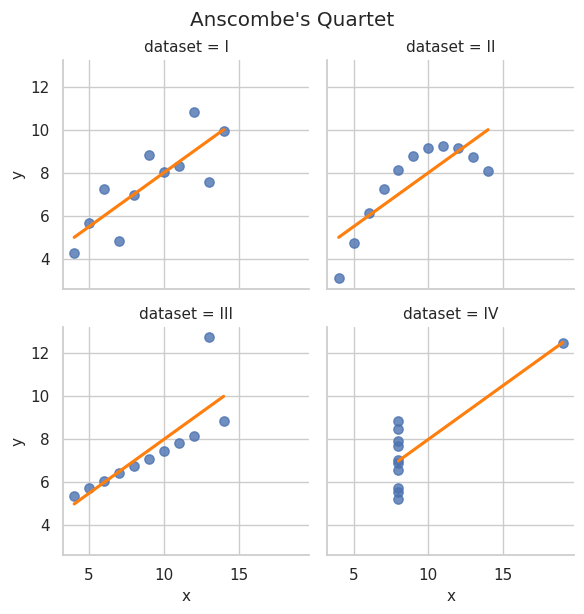

In [47]:
anscombe_values = {
    "I": (
        [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
        [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68],
    ),
    "II": (
        [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
        [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74],
    ),
    "III": (
        [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
        [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73],
    ),
    "IV": (
        [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8],
        [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89],
    ),
}
anscombe = pd.concat(
    [
        pd.DataFrame({"dataset": label, "x": x_values, "y": y_values})
        for label, (x_values, y_values) in anscombe_values.items()
    ],
    ignore_index=True,
)
summary = (
    anscombe.groupby("dataset")
    .agg(
        x_mean=("x", "mean"),
        y_mean=("y", "mean"),
        x_var=("x", "var"),
        y_var=("y", "var"),
    )
    .round(2)
)
display(summary)

grid = sns.lmplot(
    data=anscombe,
    x="x",
    y="y",
    col="dataset",
    col_wrap=2,
    ci=None,
    height=3,
    scatter_kws={"s": 45},
    line_kws={"color": "tab:orange"},
)
grid.fig.suptitle("Anscombe's Quartet", y=1.02)
plt.show()

### 4.2 Matplotlib OOP style

Dùng `fig, ax = plt.subplots()` giúp code rõ đối tượng nào đang được sửa,
đặc biệt khi có nhiều subplot. Các chart tiếp theo đều dùng pattern này.

Figure(700x420)
Axes(0.125,0.11;0.775x0.77)


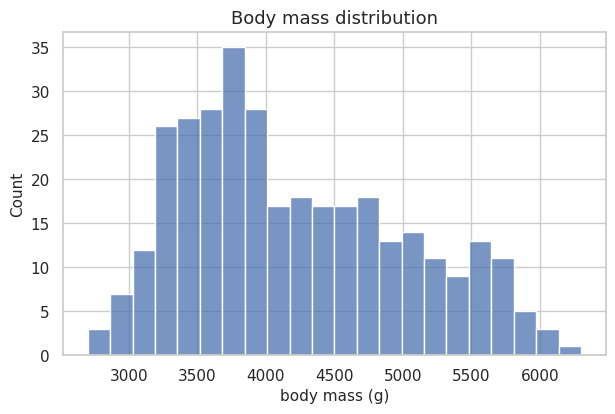

In [48]:
fig, ax = plt.subplots(figsize=(7, 4.2))
print(fig)
print(ax)
sns.histplot(data=penguins_clean, x="body_mass_g", bins=22, ax=ax)
ax.set_title("Body mass distribution")
ax.set_xlabel("body mass (g)")
plt.show()

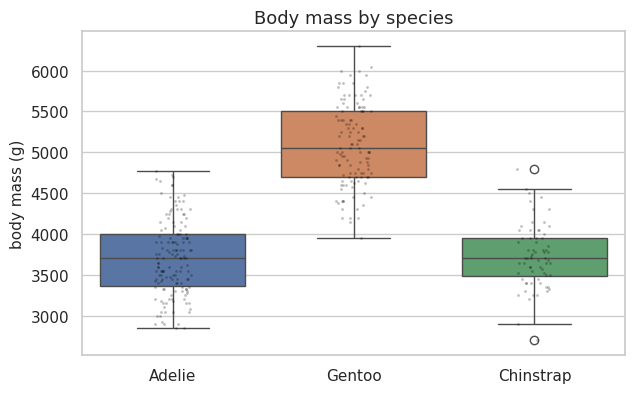

In [35]:
fig, ax = plt.subplots(figsize=(7, 4.2))
sns.boxplot(data=penguins_clean, x="species", y="body_mass_g", hue="species", legend=False, ax=ax)
sns.stripplot(data=penguins_clean, x="species", y="body_mass_g", color="black", size=2, alpha=0.25, ax=ax)
ax.set_title("Body mass by species")
ax.set_xlabel("")
ax.set_ylabel("body mass (g)")
plt.show()

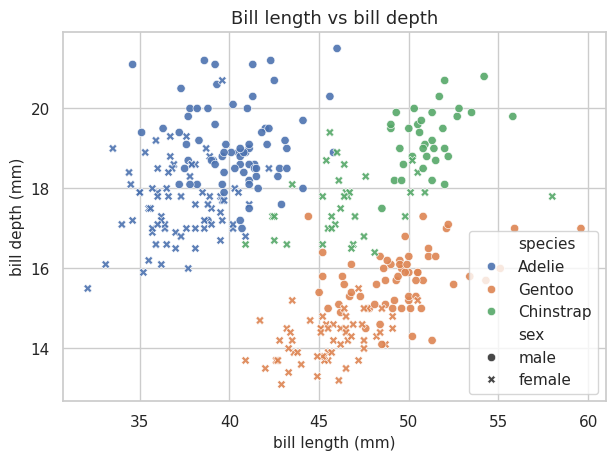

In [36]:
fig, ax = plt.subplots(figsize=(7, 4.8))
sns.scatterplot(
    data=penguins_clean,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    style="sex",
    alpha=0.9,
    ax=ax,
)
ax.set_title("Bill length vs bill depth")
ax.set_xlabel("bill length (mm)")
ax.set_ylabel("bill depth (mm)")
plt.show()

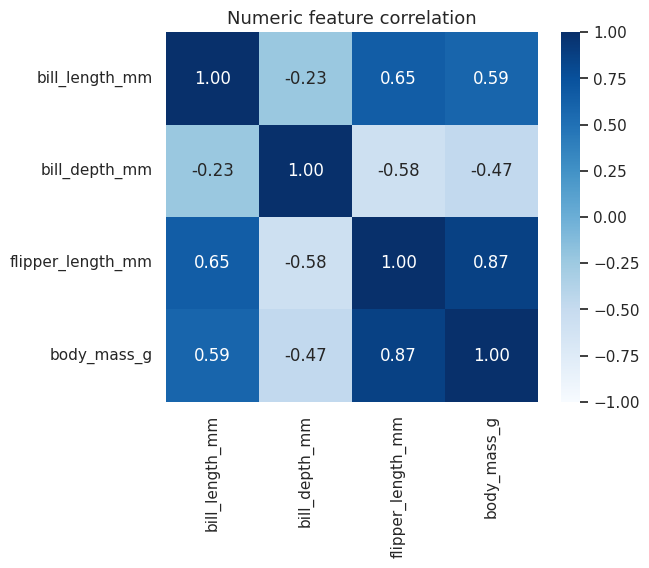

In [37]:
numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
corr = penguins_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 4.8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1, ax=ax)
ax.set_title("Numeric feature correlation")
plt.show()

### Cách đọc nhanh

- Histogram: body mass tập trung nhiều quanh khoảng 3.5-4.0kg và có nhóm nặng hơn.
- Boxplot: Gentoo nặng hơn rõ rệt trong dataset này.
- Scatter: bill length/depth tạo cụm khá rõ theo species.
- Heatmap: flipper length và body mass tương quan mạnh.

### Bài tập Visualization

Hãy tạo một chart để trả lời câu hỏi: `body_mass_g` khác nhau thế nào theo `species` và `sex`?
Sau đó viết một câu insight ngắn.

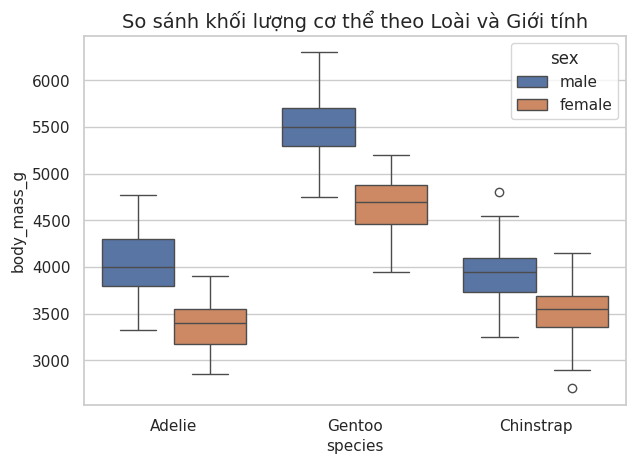

Insight: Loài Gentoo có khối lượng cơ thể nặng vượt trội so với Adelie và Chinstrap. 
Ở cả 3 loài, con đực luôn có khối lượng nặng hơn con cái.


In [56]:
# TODO: vẽ chart so sánh body_mass_g theo species và sex
# Gợi ý: sns.barplot hoặc sns.boxplot với hue="sex"
fig, ax = plt.subplots(figsize=(7,4.8))
sns.boxplot(
    data=penguins_clean,
    x = "species",
    y = "body_mass_g",
    ax = ax,
    hue = "sex",
    # legend = False,
)
plt.title("So sánh khối lượng cơ thể theo Loài và Giới tính", fontsize=14)
plt.show()
# TODO: viết một câu insight ngắn từ chart
print("Insight: Loài Gentoo có khối lượng cơ thể nặng vượt trội so với Adelie và Chinstrap. \nỞ cả 3 loài, con đực luôn có khối lượng nặng hơn con cái.")

## 5. Checklist trước khi modeling

- Đã biết shape, dtypes và missing values.
- Đã phân biệt numeric/categorical features.
- Đã xử lý missing values có lý do.
- Đã kiểm tra groupby và visualization chính.
- Đã tránh data leakage khi chuẩn hóa/impute.
- Đã chuyển dữ liệu cuối cùng về dạng matrix/tensor phù hợp khi cần.